# Student Performance Prediction System
### Data Preprocessing · Feature Selection · Model Training · Evaluation · Model Saving

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
import warnings
warnings.filterwarnings('ignore')

os.makedirs('models', exist_ok=True)
print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
import sys
print(sys.executable)

C:\Users\M Qasim\Downloads\student_app\myenv\Scripts\python.exe


## 1. Load Dataset

In [3]:
df = pd.read_csv('student_performance.csv')
print('Shape:', df.shape)
df.head()

Shape: (400, 13)


,Student_ID,Attendance_Rate(%),Study_Hours_Per_Day,Previous_Marks,Assignment_Score,Quiz_Score,Class_Participation(1-10),Sleep_Hours_Per_Day,Stress_Level(1-10),Internet_Access(0/1),Parental_Support(1-5),Final_Score,Result
0,1,78.4,1.2,49.3,37.9,78.9,9,4.5,7,0,1,46.4,Fail
1,2,76.1,6.1,80.1,76.1,53.6,8,7.5,1,0,4,67.2,Pass
2,3,60.4,2.4,97.0,46.9,27.4,2,6.2,6,1,1,48.9,Fail
3,4,98.4,4.4,68.6,86.4,69.5,6,7.5,2,0,2,62.8,Pass
4,5,86.4,9.9,89.9,89.3,50.4,8,7.8,6,0,3,71.9,Pass


In [4]:
df.describe()

,Student_ID,Attendance_Rate(%),Study_Hours_Per_Day,Previous_Marks,Assignment_Score,Quiz_Score,Class_Participation(1-10),Sleep_Hours_Per_Day,Stress_Level(1-10),Internet_Access(0/1),Parental_Support(1-5),Final_Score
count,400.000000,400.000000,400.00000,400.000000,400.000000,400.00000,400.000000,400.000000,400.00000,400.000000,400.00000,400.000000
mean,200.500000,69.640000,5.58375,64.759750,60.437250,60.32725,5.615000,6.901500,5.61000,0.472500,2.97000,56.535750
std,115.614301,17.835627,2.48327,19.181914,23.090605,22.53043,2.775976,1.786442,2.93589,0.499868,1.42273,8.995315
min,1.000000,40.200000,1.00000,30.300000,20.600000,20.20000,1.000000,4.000000,1.00000,0.000000,1.00000,35.300000
25%,100.750000,54.275000,3.40000,49.875000,40.075000,41.95000,3.000000,5.400000,3.00000,0.000000,2.00000,50.000000
50%,200.500000,68.700000,5.65000,64.950000,60.700000,60.90000,6.000000,6.700000,6.00000,0.000000,3.00000,55.950000
75%,300.250000,85.525000,7.60000,79.950000,80.475000,78.02500,8.000000,8.500000,8.00000,1.000000,4.00000,62.925000
max,400.000000,99.800000,10.00000,99.900000,99.900000,99.50000,10.000000,10.000000,10.00000,1.000000,5.00000,84.300000


## 2. Data Preprocessing

In [5]:
# Check missing values
print('Missing values:')
print(df.isnull().sum())

# Features and targets
feats = [
    'Attendance_Rate(%)', 'Study_Hours_Per_Day', 'Previous_Marks',
    'Assignment_Score', 'Quiz_Score', 'Class_Participation(1-10)',
    'Sleep_Hours_Per_Day', 'Stress_Level(1-10)',
    'Internet_Access(0/1)', 'Parental_Support(1-5)'
]

X     = df[feats].values
y_cls = (df['Result'] == 'Pass').astype(int).values
y_reg = df['Final_Score'].values

print('\nPass:', y_cls.sum(), '| Fail:', (1 - y_cls).sum())

Missing values:
Student_ID                   0
Attendance_Rate(%)           0
Study_Hours_Per_Day          0
Previous_Marks               0
Assignment_Score             0
Quiz_Score                   0
Class_Participation(1-10)    0
Sleep_Hours_Per_Day          0
Stress_Level(1-10)           0
Internet_Access(0/1)         0
Parental_Support(1-5)        0
Final_Score                  0
Result                       0
dtype: int64

Pass: 302 | Fail: 98


In [6]:
# Standard Scaling
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
print('Scaling done. Mean ~0:', Xs.mean(axis=0).round(2))

Scaling done. Mean ~0: [-0. -0.  0.  0.  0. -0. -0. -0.  0. -0.]


## 3. Feature Selection

In [7]:
# SelectKBest - top 8 features
sel_c = SelectKBest(f_classif, k=8).fit(Xs, y_cls)
sel_r = SelectKBest(f_regression, k=8).fit(Xs, y_reg)

Xc = sel_c.transform(Xs)
Xr = sel_r.transform(Xs)

selected_cls = [feats[i] for i in range(len(feats)) if sel_c.get_support()[i]]
selected_reg = [feats[i] for i in range(len(feats)) if sel_r.get_support()[i]]

print('Selected for Classification:', selected_cls)
print('Selected for Regression:', selected_reg)

Selected for Classification: ['Attendance_Rate(%)', 'Study_Hours_Per_Day', 'Previous_Marks', 'Assignment_Score', 'Quiz_Score', 'Class_Participation(1-10)', 'Stress_Level(1-10)', 'Internet_Access(0/1)']
Selected for Regression: ['Attendance_Rate(%)', 'Study_Hours_Per_Day', 'Previous_Marks', 'Assignment_Score', 'Quiz_Score', 'Class_Participation(1-10)', 'Stress_Level(1-10)', 'Internet_Access(0/1)']


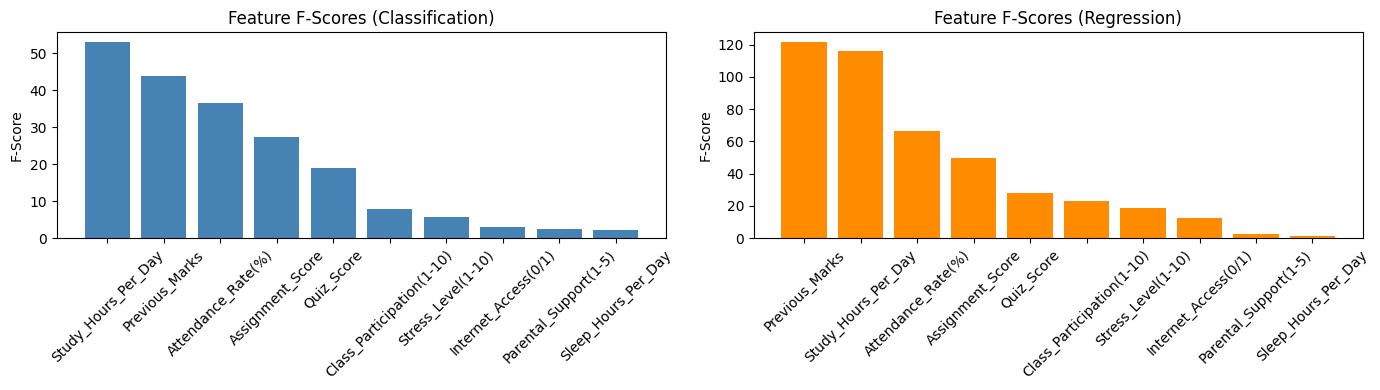

In [8]:
# Feature importance plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

scores_c = sel_c.scores_
order_c  = np.argsort(scores_c)[::-1]
axes[0].bar([feats[i] for i in order_c], scores_c[order_c], color='steelblue')
axes[0].set_title('Feature F-Scores (Classification)')
axes[0].set_ylabel('F-Score')
axes[0].tick_params(axis='x', rotation=45)

scores_r = sel_r.scores_
order_r  = np.argsort(scores_r)[::-1]
axes[1].bar([feats[i] for i in order_r], scores_r[order_r], color='darkorange')
axes[1].set_title('Feature F-Scores (Regression)')
axes[1].set_ylabel('F-Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Train-Test Split

In [9]:
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, y_reg, test_size=0.2, random_state=42)

print('Classification — Train:', Xc_tr.shape, '| Test:', Xc_te.shape)
print('Regression    — Train:', Xr_tr.shape, '| Test:', Xr_te.shape)

Classification — Train: (320, 8) | Test: (80, 8)
Regression    — Train: (320, 8) | Test: (80, 8)


## 5. Model Training

In [10]:
# Classification models
lr = LogisticRegression(max_iter=500, random_state=42)
nb = GaussianNB()
lr.fit(Xc_tr, yc_tr)
nb.fit(Xc_tr, yc_tr)
print('Classification models trained!')

# Regression models
rid = Ridge(alpha=1.0)
las = Lasso(alpha=0.1)
rid.fit(Xr_tr, yr_tr)
las.fit(Xr_tr, yr_tr)
print('Regression models trained!')

Classification models trained!
Regression models trained!


## 6. Model Evaluation

In [11]:
lr_acc  = accuracy_score(yc_te, lr.predict(Xc_te))
nb_acc  = accuracy_score(yc_te, nb.predict(Xc_te))
rid_mse = mean_squared_error(yr_te, rid.predict(Xr_te))
las_mse = mean_squared_error(yr_te, las.predict(Xr_te))
rid_r2  = r2_score(yr_te, rid.predict(Xr_te))
las_r2  = r2_score(yr_te, las.predict(Xr_te))

results = pd.DataFrame({
    'Model':         ['Logistic Regression', 'Naive Bayes', 'Ridge Regression', 'Lasso Regression'],
    'Type':          ['Classification', 'Classification', 'Regression', 'Regression'],
    'Accuracy / R²': [f'{lr_acc*100:.2f}%', f'{nb_acc*100:.2f}%', f'{rid_r2:.4f}', f'{las_r2:.4f}'],
    'Error (MSE)':   [f'{(1-lr_acc)*100:.2f}%', f'{(1-nb_acc)*100:.2f}%', f'{rid_mse:.4f}', f'{las_mse:.4f}']
})
print(results.to_string(index=False))

              Model           Type Accuracy / R² Error (MSE)
Logistic Regression Classification        91.25%       8.75%
        Naive Bayes Classification        83.75%      16.25%
   Ridge Regression     Regression        0.8390     12.7693
   Lasso Regression     Regression        0.8389     12.7781


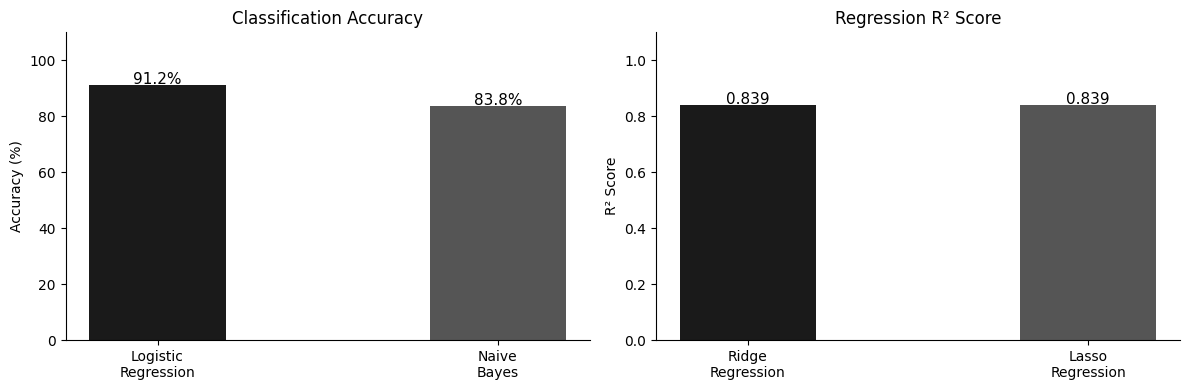


Best Classifier : Logistic Regression (91.25%)
Best Regressor  : Ridge Regression (R²=0.8390)


In [12]:
# Model comparison charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Classification accuracy
axes[0].bar(['Logistic\nRegression', 'Naive\nBayes'],
            [lr_acc*100, nb_acc*100], color=['#1a1a1a', '#555'], width=0.4)
for i, v in enumerate([lr_acc*100, nb_acc*100]):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)
axes[0].set_ylim(0, 110)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Classification Accuracy')
axes[0].spines[['top','right']].set_visible(False)

# Regression R2
axes[1].bar(['Ridge\nRegression', 'Lasso\nRegression'],
            [rid_r2, las_r2], color=['#1a1a1a', '#555'], width=0.4)
for i, v in enumerate([rid_r2, las_r2]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('R² Score')
axes[1].set_title('Regression R² Score')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# Best models
best_cls = 'Logistic Regression' if lr_acc >= nb_acc else 'Naive Bayes'
best_reg = 'Ridge Regression' if rid_r2 >= las_r2 else 'Lasso Regression'
print(f'\nBest Classifier : {best_cls} ({max(lr_acc, nb_acc)*100:.2f}%)')
print(f'Best Regressor  : {best_reg} (R²={max(rid_r2, las_r2):.4f})')

## 7. Correlation Heatmap

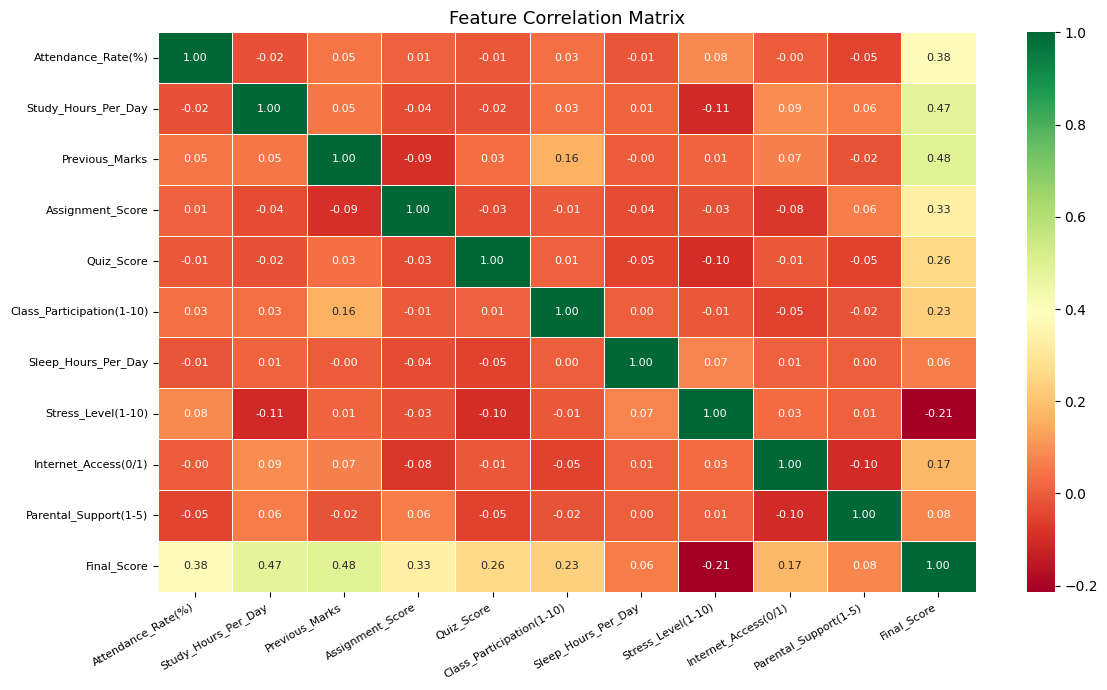

In [16]:
plt.figure(figsize=(12, 7))
corr = df[feats + ['Final_Score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.4, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Save Models

In [17]:
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(sel_c,  'models/selector_cls.pkl')
joblib.dump(sel_r,  'models/selector_reg.pkl')
joblib.dump(lr,     'models/logistic.pkl')
joblib.dump(nb,     'models/naive_bayes.pkl')
joblib.dump(rid,    'models/ridge.pkl')
joblib.dump(las,    'models/lasso.pkl')

print('All models saved in models/ folder!')
print('Now run:  streamlit run app.py')

All models saved in models/ folder!
Now run:  streamlit run app.py
